In [2]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

# Use the exact filename as it appears in your Jupyter file browser
df = pd.read_csv('MD_agric_exam-4313.csv')
df.head()

,Field_ID,Elevation,Rainfall,Min_temperature_C,Max_temperature_C,pH,Pollution_level,Plot_size,Annual_yield,Crop_type
0,1162,494.95615,1507.6,-5.4,31.0,6.859436,0.007034,3.6,1.617421,coffee
1,5108,663.73390,581.0,-4.7,30.9,5.603219,0.289643,4.2,2.532497,potato
2,3504,396.87990,1715.1,-6.1,31.7,5.774116,0.000409,2.6,1.262207,banana
3,5351,594.80370,1748.0,-4.3,33.6,6.477415,0.088777,7.9,4.351564,wheat
4,905,609.49800,1395.8,-4.5,31.3,5.419586,0.050023,10.8,5.034791,cassava


In [3]:
# .nunique() counts distinct values in a column
num_unique = df['Crop_type'].nunique()
print('Number of unique crop types:', num_unique)

# .unique() shows what those values are
print('Crop types:', df['Crop_type'].unique())

Number of unique crop types: 8
Crop types: ['coffee' 'potato' 'banana' 'wheat' 'cassava' 'maize' 'tea' 'rice']


In [4]:
# Step 1: filter to wheat rows only
wheat_df = df[df['Crop_type'] == 'wheat']

# Step 2: get the max yield and round
max_wheat_yield = wheat_df['Annual_yield'].max()
print('Max annual yield for wheat:', round(max_wheat_yield, 2))

Max annual yield for wheat: 8.99


In [5]:
# Step 1: calculate average pollution per crop type
avg_pollution = df.groupby('Crop_type')['Pollution_level'].mean()
print('Avg pollution per crop:\n', avg_pollution.sort_values(ascending=False))

# Step 2: find crops where avg pollution > 0.2
crops_above = avg_pollution[avg_pollution > 0.2].index
print('\nCrops above 0.2:', list(crops_above))

# Step 3: filter df to those crops and sum Rainfall
total_rainfall = df[df['Crop_type'].isin(crops_above)]['Rainfall'].sum()
print('\nTotal rainfall:', round(total_rainfall, 1))

Avg pollution per crop:
 Crop_type
cassava    0.327714
maize      0.265101
potato     0.252135
wheat      0.223527
coffee     0.220615
tea        0.214799
banana     0.093806
rice       0.065531
Name: Pollution_level, dtype: float64

Crops above 0.2: ['cassava', 'coffee', 'maize', 'potato', 'tea', 'wheat']

Total rainfall: 941959.7


In [6]:
# Define the function
def temp_range(field_id):
    row = df[df['Field_ID'] == field_id]
    max_temp = row['Max_temperature_C'].values[0]
    min_temp = row['Min_temperature_C'].values[0]
    return round(max_temp - min_temp, 1)

# Call it for each Field_ID
print('Field 1458:', temp_range(1458))
print('Field 1895:', temp_range(1895))
print('Field 5443:', temp_range(5443))

Field 1458: 40.7
Field 1895: 35.7
Field 5443: 33.4


In [7]:
# --- Original exam code, with added explanation comments ---
a = df['Crop_type'].unique()    # all unique crop types
b = float('inf')                # tracker: starts at infinity so any real value beats it
c = ''                          # tracker: stores the winning crop name

for crop in a:
    d = df[df['Crop_type'] == crop]['Min_temperature_C'].mean()  # avg min temp for this crop
    if d < b:       # if this crop has a lower avg min temp than the current best
        b = d       # update the best value
        c = crop    # update the winning crop

print('Crop with lowest avg min temperature:', c)
print('Its avg min temperature:', round(b, 2))

# One-liner pandas equivalent
print('\nPandas equivalent:')
print(df.groupby('Crop_type')['Min_temperature_C'].mean().idxmin())

Crop with lowest avg min temperature: rice
Its avg min temperature: -6.46

Pandas equivalent:
rice


In [8]:
# Filter rows where pH is below 5.5
low_ph = df[df['pH'] < 5.5]
print('Rows with pH < 5.5:', len(low_ph))

# Sum the Plot_size for those rows
total_plot_size = low_ph['Plot_size'].sum()
print('Total plot size:', round(total_plot_size, 1))

Rows with pH < 5.5: 469
Total plot size: 1731.9


In [9]:
# Both conditions must be in parentheses when using &
filtered = df[(df['Min_temperature_C'] < -5) & (df['Max_temperature_C'] > 30)]

print('Number of matching rows:', len(filtered))
filtered[['Field_ID', 'Min_temperature_C', 'Max_temperature_C']].head()

Number of matching rows: 319


,Field_ID,Min_temperature_C,Max_temperature_C
0,1162,-5.4,31.0
2,3504,-6.1,31.7
5,2274,-7.2,34.3
13,4807,-6.3,32.9
14,973,-6.0,30.2


In [10]:
# Step 1: find the median plot size
median_plot = df['Plot_size'].median()
print('Median plot size:', median_plot)

# Step 2: filter to plots larger than the median
large_plots = df[df['Plot_size'] > median_plot]
print('Number of large plots:', len(large_plots))

# Step 3: calculate std dev using numpy
# ddof=0 → population std dev (numpy default) → matches answer 469.62
# ddof=1 → sample std dev                     → gives 470.09
std_ddof0 = np.std(large_plots['Rainfall'], ddof=0)
std_ddof1 = np.std(large_plots['Rainfall'], ddof=1)

print('\nStd dev (ddof=0):', round(std_ddof0, 2))
print('Std dev (ddof=1):', round(std_ddof1, 2))

Median plot size: 2.9
Number of large plots: 497

Std dev (ddof=0): 469.62
Std dev (ddof=1): 470.09


In [11]:
# Part 1: most common Max_temperature_C
most_common_temp = df['Max_temperature_C'].mode()[0]
print('Most common Max_temperature_C:', most_common_temp)

first_3 = str(most_common_temp)[:3]   # '30.7' → '30.'
print('First 3 characters:', first_3)

# Part 2: least common crop type
crop_counts = df['Crop_type'].value_counts()
print('\nCrop counts:\n', crop_counts)

least_common = crop_counts.index[-1]  # last entry = least frequent
print('\nLeast common crop:', least_common)

last_3 = least_common[-3:]            # 'rice' → 'ice'
print('Last 3 letters:', last_3)

# Concatenate
result = first_3 + last_3
print('\nFinal answer:', result)

Most common Max_temperature_C: 30.7
First 3 characters: 30.

Crop counts:
 Crop_type
wheat      244
potato     146
cassava    141
tea        137
banana     103
coffee      99
maize       82
rice        48
Name: count, dtype: int64

Least common crop: rice
Last 3 letters: ice

Final answer: 30.ice


Elevation_category
High      615
Medium    333
Low        52
Name: count, dtype: int64


/tmp/ipykernel_14954/4080223996.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


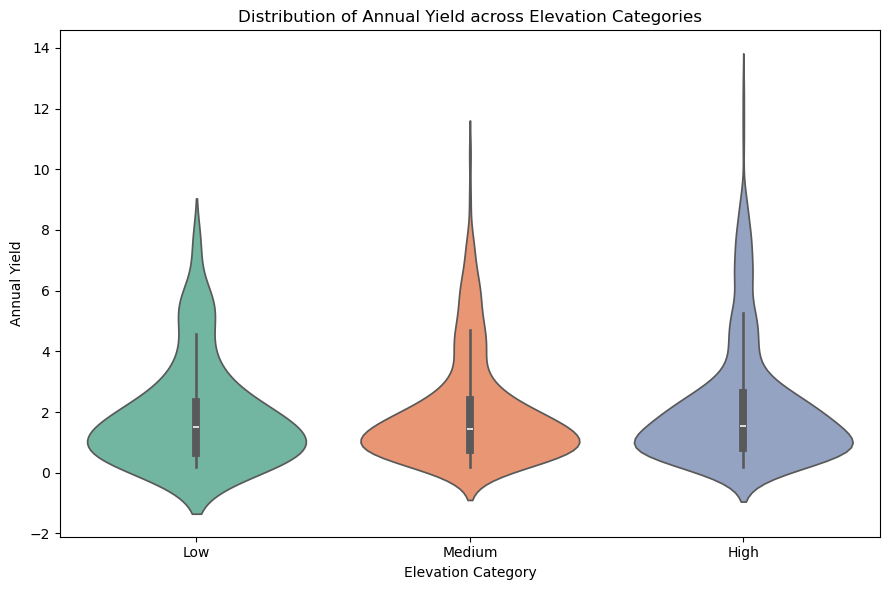

In [12]:
# Step 1: categorise elevation
def categorize_elevation(e):
    if e < 300:
        return 'Low'
    elif e <= 600:
        return 'Medium'
    else:
        return 'High'

df['Elevation_category'] = df['Elevation'].apply(categorize_elevation)
print(df['Elevation_category'].value_counts())

# Step 2: draw the violin plot
plt.figure(figsize=(9, 6))
sns.violinplot(
    x='Elevation_category',
    y='Annual_yield',
    data=df,
    order=['Low', 'Medium', 'High'],
    palette='Set2'
)
plt.title('Distribution of Annual Yield across Elevation Categories')
plt.xlabel('Elevation Category')
plt.ylabel('Annual Yield')
plt.tight_layout()
plt.show()

In [13]:
unique_crops = df['Crop_type'].unique().tolist()
print('Crops:', unique_crops)
print('Lengths:', [len(c) for c in unique_crops])

# Recursive function
def recursive_sum(crops, index=0):
    if index == len(crops):           # base case: no more crops
        return 0
    return len(crops[index]) + recursive_sum(crops, index + 1)  # recursive case

result = recursive_sum(unique_crops)
print('\nRecursive sum:', result)

# Verify
print('Manual check:', sum(len(c) for c in unique_crops))

Crops: ['coffee', 'potato', 'banana', 'wheat', 'cassava', 'maize', 'tea', 'rice']
Lengths: [6, 6, 6, 5, 7, 5, 3, 4]

Recursive sum: 42
Manual check: 42


In [14]:
# Extract yields for each crop
coffee_yield = df[df['Crop_type'] == 'coffee']['Annual_yield']
banana_yield = df[df['Crop_type'] == 'banana']['Annual_yield']

print('Coffee — n:', len(coffee_yield), '| mean:', round(coffee_yield.mean(), 3))
print('Banana — n:', len(banana_yield), '| mean:', round(banana_yield.mean(), 3))

# Run the t-test
t_stat, p_val = stats.ttest_ind(coffee_yield, banana_yield)

print('\nT-statistic:', round(t_stat, 4))
print('P-value:    ', round(p_val, 3))

# Interpret
if p_val < 0.05:
    print('\nSignificant difference between coffee and banana yields (p < 0.05)')
else:
    print('\nNo significant difference (p >= 0.05) — yields are statistically similar')

Coffee — n: 99 | mean: 1.949
Banana — n: 103 | mean: 2.077

T-statistic: -0.5277
P-value:     0.598

No significant difference (p >= 0.05) — yields are statistically similar
